# Step 1: Import Python Libraries. #

In [1]:
import os
import sys
import glob
import string
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Exploratory Data Analysis. #

In [2]:
print("-- Checking the path. --")
#-- Import folder directories --#
train_data = '../Datasets/Train/EngText/'
test_data = '../Datasets/Test/EngText/'
#-- Check that the directory is correct or not. --#
if os.path.exists(train_data):
    print(f"The directory {train_data} exists.")
    if os.path.exists(test_data):
        print(f"The directory {test_data} exists")
    else:
        print("WARNING! Please check the folder direcotry again please.")
else:
    print("WARNING: Please check the directory is correct or not.")
print("-- Progress Finish. --")


-- Checking the path. --
The directory ../Datasets/Train/EngText/ exists.
The directory ../Datasets/Test/EngText/ exists
-- Progress Finish. --


In [3]:
#-- PURPOSE: Discover Training folder and its internal folder. --#
print("-- Discover Training folder path and its internal. --#")

train_files = glob.glob(os.path.join(train_data, "*.csv"))
if train_files:
    print("-- Scanning files: --")
    for file_id, file_path in enumerate(sorted(train_files), 1):
        print(f"{file_id}: {os.path.basename(file_path)}")
else:
    print('Error')

-- Discover Training folder path and its internal. --#
-- Scanning files: --
1: Datasets_01.csv
2: Datasets_02.csv
3: Datasets_03.csv
4: Datasets_04.csv
5: Datasets_05.csv
6: Datasets_06.csv
7: Datasets_07.csv
8: Datasets_08.csv
9: Datasets_09.csv
10: Datasets_10.csv
11: Datasets_11.csv
12: Datasets_12.csv
13: Datasets_13.csv
14: Datasets_14.csv
15: Datasets_15.csv


In [4]:
#-- PURPOSE: Discover Test folder and its internal folder. --#
print("-- Discover Test folder path and its internal. --#")

test_files = glob.glob(os.path.join(test_data, "*.csv"))
if test_files:
    print("-- Scanning files: --")
    for file_id, file_path in enumerate(sorted(test_files), 1):
        print(f"{file_id}: {os.path.basename(file_path)}")
else:
    print('Error')

-- Discover Test folder path and its internal. --#
-- Scanning files: --
1: Datasets_01.csv
2: Datasets_02.csv
3: Datasets_03.csv
4: Datasets_04.csv


In [5]:
if 'train_files' in locals() and train_files:
    print("-- Reading internal files to parse alphabet distribution. --")
    #-- Load and merge all 15 CSV files into a temporary dataframe. --#
    df_list = [pd.read_csv(file) for file in train_files]
    df_train_temp = pd.concat(df_list, ignore_index=True)
    #-- Identify the label column (assuming it's the first column). --#
    label_col = df_train_temp.columns[0]
    total_rows = len(df_train_temp)
    # Count occurrences of each unique raw index/label. --#
    raw_counts = df_train_temp[label_col].value_counts().sort_index()
    #-- Map standard numeric labels (0-25) to English Alphabet (A-Z). --#
    alphabet_map = list(string.ascii_uppercase)

    print("\n -- TRAINING FOLDER LETTER DISTRIBUTION --")
    print(f"Total rows combined: {total_rows}\n")
    
    for label_val, count in raw_counts.items():
        if isinstance(label_val, (int, np.integer)) and 0 <= label_val < 26:
            letter_char = alphabet_map[int(label_val)]
            print(f"Letter {letter_char}: {count:5d} rows")
        else:
            print(f"Letter {label_val}: {count:5d} rows")
            
else:
    print("ERROR")

-- Reading internal files to parse alphabet distribution. --

 -- TRAINING FOLDER LETTER DISTRIBUTION --
Total rows combined: 297960

Letter A: 11019 rows
Letter B:  6928 rows
Letter C: 18704 rows
Letter D:  8080 rows
Letter E:  9143 rows
Letter F:   922 rows
Letter G:  4632 rows
Letter H:  5769 rows
Letter I:   907 rows
Letter J:  6791 rows
Letter K:  4461 rows
Letter L:  9294 rows
Letter M:  9849 rows
Letter N: 15156 rows
Letter O: 46276 rows
Letter P: 15424 rows
Letter Q:  4638 rows
Letter R:  9313 rows
Letter S: 38655 rows
Letter T: 18057 rows
Letter U: 23261 rows
Letter V:  3332 rows
Letter W:  8711 rows
Letter X:  5076 rows
Letter Y:  8698 rows
Letter Z:  4864 rows


Saved figure to ..\Figures\Letter_Distribution.png


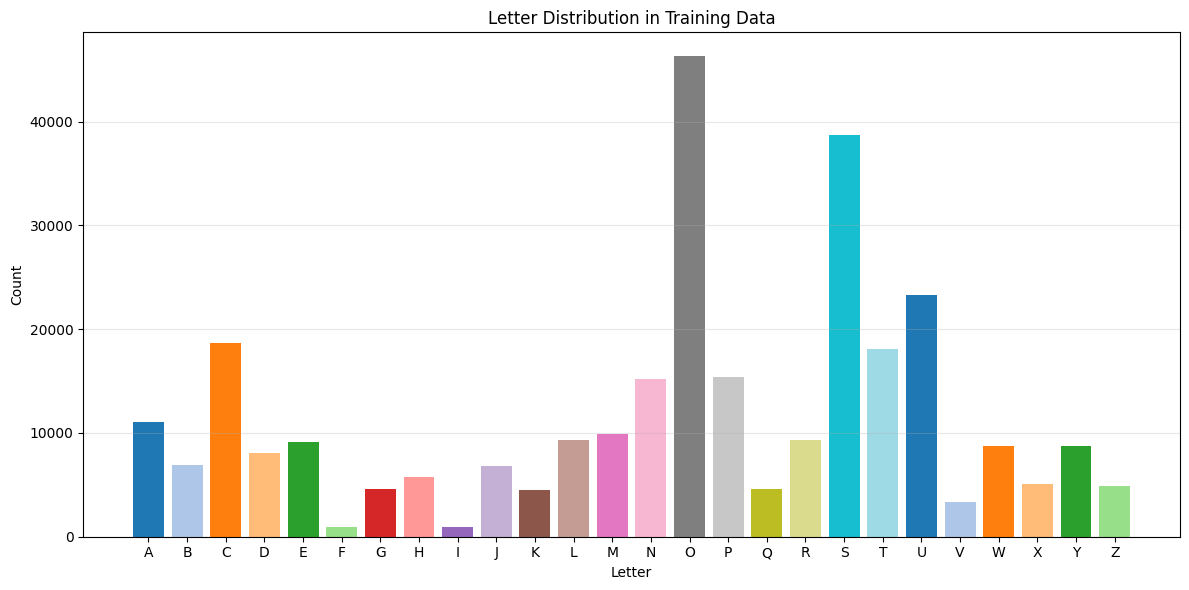

In [6]:
if 'df_train_temp' in locals():
    label_col = df_train_temp.columns[0]
    raw_counts = df_train_temp[label_col].value_counts().sort_index()
    alphabet_map = list(string.ascii_uppercase)

    letters = [alphabet_map[i] for i in range(26)]
    counts = [raw_counts.get(i, 0) for i in range(26)]

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = sns.color_palette("tab20", 26)
    ax.bar(letters, counts, color=colors)
    ax.set_title("Letter Distribution in Training Data")
    ax.set_xlabel("Letter")
    ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    os.makedirs("../Figures", exist_ok=True)
    fig_path = os.path.join("..", "Figures", "Letter_Distribution.png")
    fig.savefig(fig_path, dpi=300)
    print(f"Saved figure to {fig_path}")
else:
    print("df_train_temp is not available. Run the earlier cell first.")

# Step 3: Custom CNN Convolutional Layer. #

In [11]:
import torch
import torch.nn as nn

In [12]:
#-- Define Stage 1. --#
stage_1 = nn.Sequential(
    #-- First Layer: Input(1) => Output(32)
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(inplace=True),
    #-- Second Layer: Input(32) => Output(32)
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(inplace=True),
    #-- Reduce size of image (28x28) -> (14x14). --#
    nn.MaxPool2d(kernel_size=2, stride=2),    
    nn.Dropout2d(p=0.10)
)
print("Stage 1 Loaded Success")

Stage 1 Loaded Success


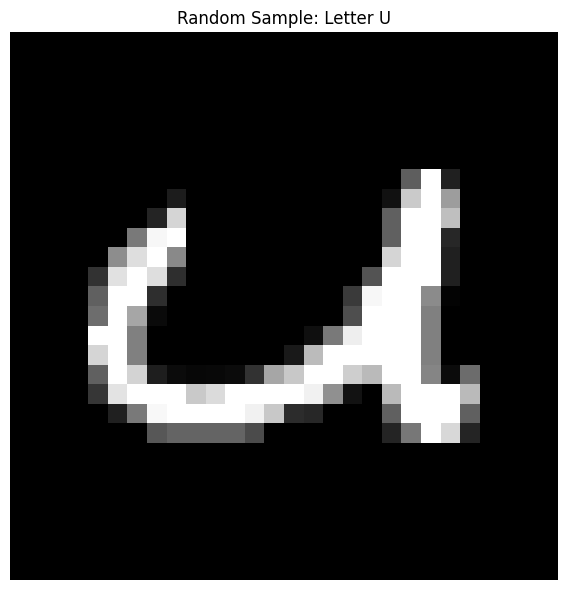

Displayed random letter: U


In [13]:
#-- Select a random letter index (0-25). --#
random_idx = np.random.randint(0, 26)
random_letter = alphabet_map[random_idx]
#-- Get a random sample from that letter class. --#
letter_samples = df_train_temp[df_train_temp['0'] == random_idx]
random_sample = letter_samples.sample(n=1)
#-- Reshape the pixel data (784 values) into 28x28 image. --#
pixel_data = random_sample.iloc[0, 1:].values.astype(np.uint8).reshape(28, 28)
#-- Display the image. --#
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(pixel_data, cmap='gray')
ax.set_title(f"Random Sample: Letter {random_letter}")
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Displayed random letter: {random_letter}")

Stage 1 progress shapes:
  input: torch.Size([1, 1, 28, 28])
  after first conv/relu: torch.Size([1, 32, 28, 28])
  after second conv/relu: torch.Size([1, 32, 28, 28])
  after pooling/dropout: torch.Size([1, 32, 14, 14])


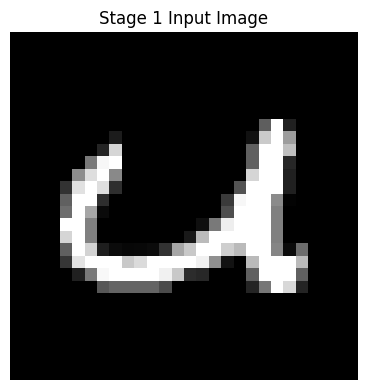

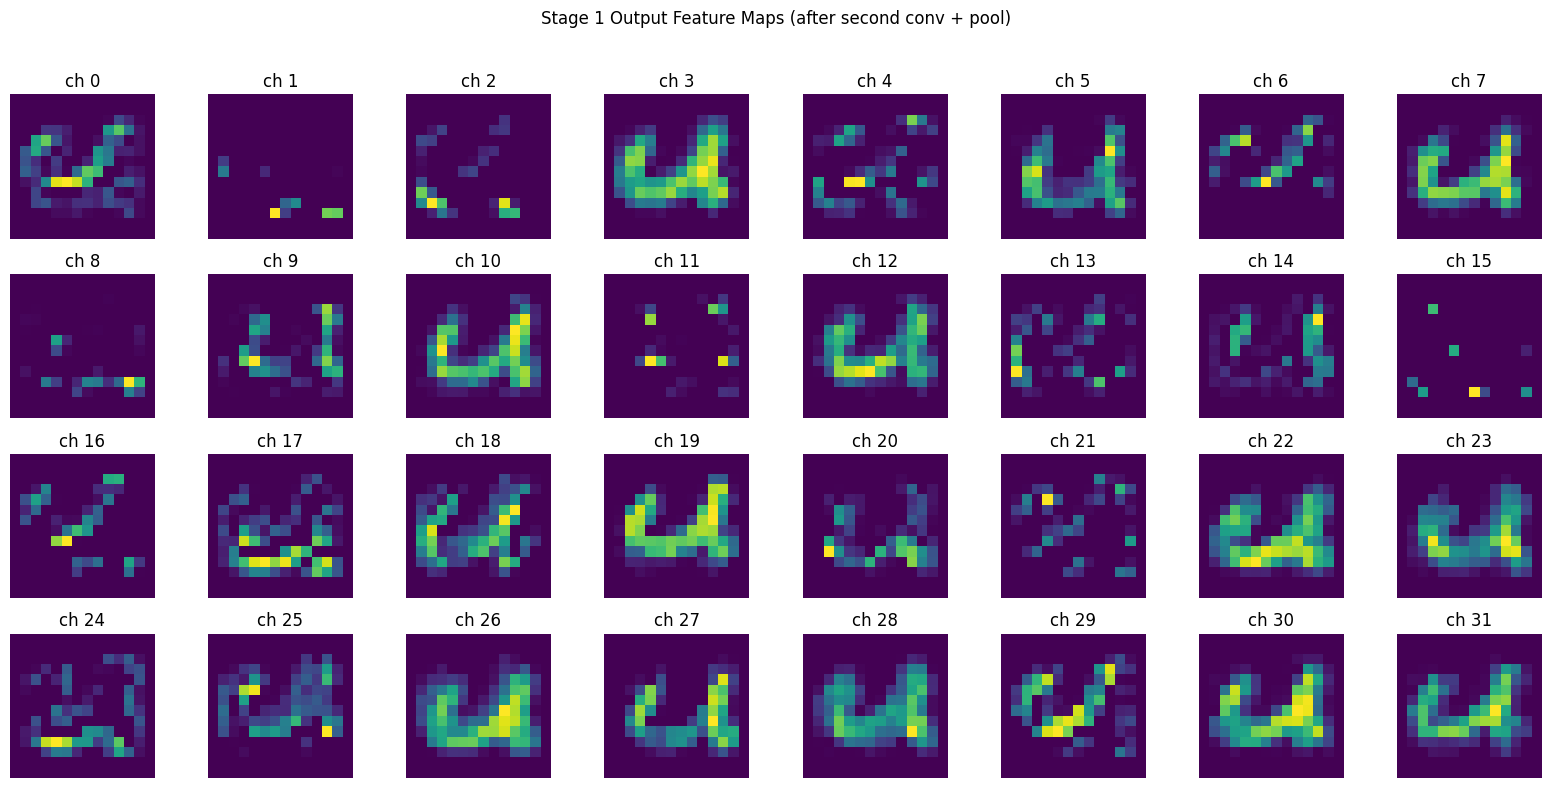

Saved stage 1 feature map image to ..\Figures\Stage1_FeatureMaps.png


In [14]:
if 'pixel_data' in locals() and 'stage_1' in locals():
    input_tensor = torch.from_numpy(pixel_data).unsqueeze(0).unsqueeze(0).float() / 255.0

    stage_1_progress = nn.Sequential(
        stage_1[0],
        stage_1[1],
        stage_1[2],
        nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        stage_1[6],
        stage_1[7]
    )
    stage_1_progress.eval()

    with torch.no_grad():
        x1 = stage_1_progress[:3](input_tensor)
        x2 = stage_1_progress[3:6](x1)
        x3 = stage_1_progress[6:](x2)

    print("Stage 1 progress shapes:")
    print("  input:", input_tensor.shape)
    print("  after first conv/relu:", x1.shape)
    print("  after second conv/relu:", x2.shape)
    print("  after pooling/dropout:", x3.shape)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(pixel_data, cmap='gray')
    ax.set_title("Stage 1 Input Image")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    n_channels = x3.shape[1]
    n_cols = 8
    n_rows = int(np.ceil(n_channels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))

    for idx, ax in enumerate(axes.flat):
        if idx < n_channels:
            fmap = x3[0, idx].cpu().numpy()
            ax.imshow(fmap, cmap='viridis')
            ax.set_title(f"ch {idx}")
        ax.axis("off")

    plt.suptitle("Stage 1 Output Feature Maps (after second conv + pool)")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    os.makedirs("../Figures", exist_ok=True)
    fig_path = os.path.join("..", "Figures", "Stage1_FeatureMaps.png")
    fig.savefig(fig_path, dpi=300)
    print(f"Saved stage 1 feature map image to {fig_path}")
else:
    print("Required variables are not available. Run the previous cells first.")

In [15]:
#-- Stage 2. --#
stage2 = nn.Sequential(
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(inplace=True),
    
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(inplace=True),
    
    nn.MaxPool2d(kernel_size=2, stride=2),    
    nn.Dropout2d(p=0.15)
)

print("Stage 2 Success!")

Stage 2 Success!


Random letter: U
Input tensor shape: torch.Size([1, 1, 28, 28])
Stage 1 output shape: torch.Size([1, 32, 14, 14])
Stage 2 output shape: torch.Size([1, 64, 7, 7])


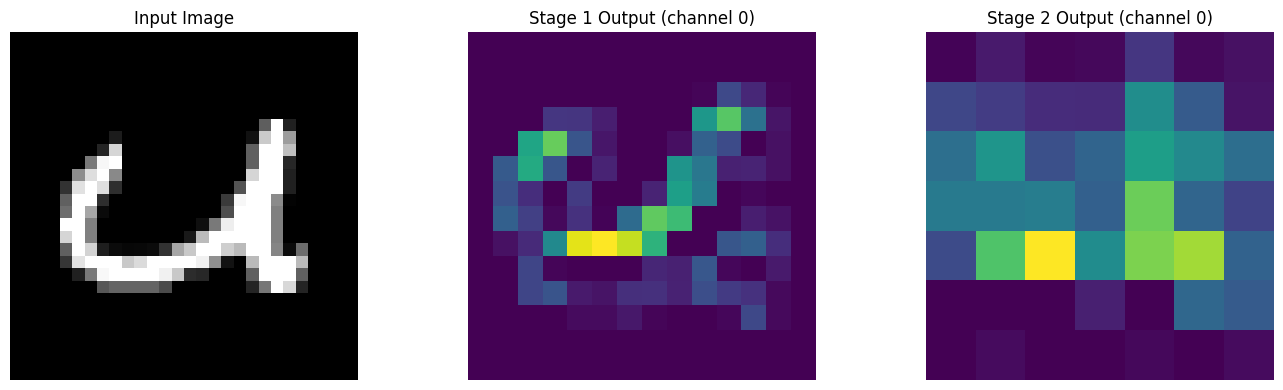

In [16]:
if 'pixel_data' in locals() and 'stage_1_progress' in locals() and 'stage2' in locals():
    input_tensor = torch.from_numpy(pixel_data).unsqueeze(0).unsqueeze(0).float() / 255.0

    stage_1_progress.eval()
    stage2.eval()

    with torch.no_grad():
        stage1_output = stage_1_progress(input_tensor)
        stage2_output = stage2(stage1_output)

    print(f"Random letter: {random_letter}")
    print("Input tensor shape:", input_tensor.shape)
    print("Stage 1 output shape:", stage1_output.shape)
    print("Stage 2 output shape:", stage2_output.shape)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(pixel_data, cmap='gray')
    axes[0].set_title("Input Image")
    axes[1].imshow(stage1_output[0, 0].cpu(), cmap='viridis')
    axes[1].set_title("Stage 1 Output (channel 0)")
    axes[2].imshow(stage2_output[0, 0].cpu(), cmap='viridis')
    axes[2].set_title("Stage 2 Output (channel 0)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Required variables are not available. Run the previous cells first.")

In [17]:
if 'fig' in locals():
    os.makedirs("../Figures", exist_ok=True)
    fig_path = os.path.join("..", "Figures", "Stage2_Progress.png")
    fig.savefig(fig_path, dpi=300)
    print(f"Saved previous figure to {fig_path}")
else:
    print("No figure object named 'fig' found. Run the previous plotting cell first.")

Saved previous figure to ..\Figures\Stage2_Progress.png


In [18]:
# --- Define Stage 3 ---
stage3 = nn.Sequential(
    # First Conv layer of Stage 3: from 64 channels to 128 channels
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=128),
    nn.ReLU(inplace=True),
    
    # Second Conv layer of Stage 3: keep 128 channels to extract maximum features
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(num_features=128),
    nn.ReLU(inplace=True),
    
    # Compress spatial dimensions down to fixed 3x3 using Adaptive Average Pooling
    nn.AdaptiveAvgPool2d(output_size=(3, 3))
)

print("Stage 3 success!")

Stage 3 success!


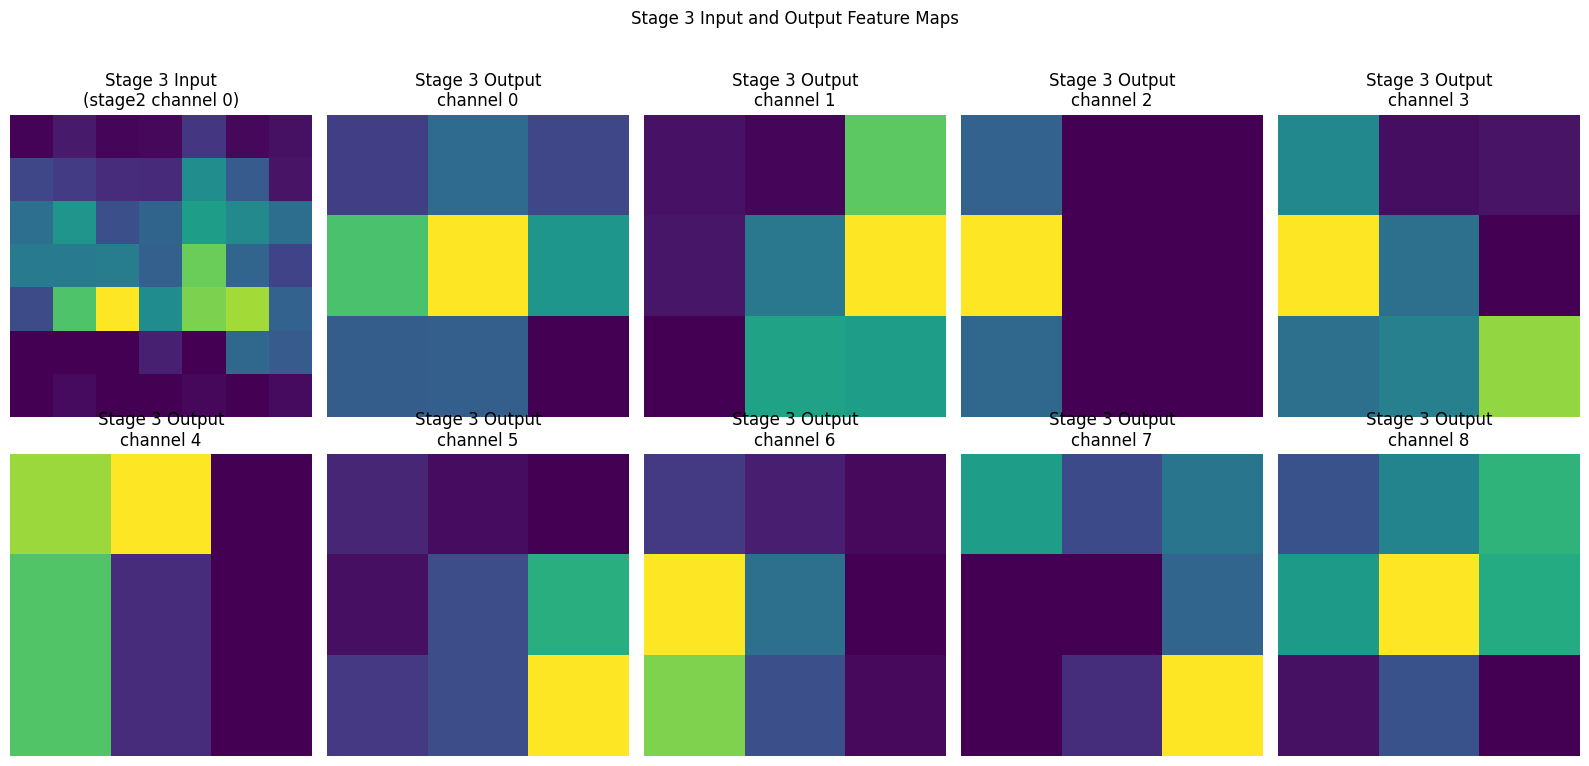

Saved figure to ..\Figures\Stage3_Input_Output.png


In [19]:
if 'stage3' in locals() and 'stage2_output' in locals():
    stage3.eval()

    with torch.no_grad():
        stage3_output = stage3(stage2_output)

    fig, axes = plt.subplots(2, 5, figsize=(16, 8))
    axes = axes.flatten()

    axes[0].imshow(stage2_output[0, 0].cpu(), cmap='viridis', interpolation='nearest')
    axes[0].set_title("Stage 3 Input\n(stage2 channel 0)")
    axes[0].axis("off")

    for idx in range(1, 10):
        fmap = stage3_output[0, idx - 1].cpu().numpy()
        axes[idx].imshow(fmap, cmap='viridis', interpolation='nearest')
        axes[idx].set_title(f"Stage 3 Output\nchannel {idx - 1}")
        axes[idx].axis("off")

    plt.suptitle("Stage 3 Input and Output Feature Maps")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    os.makedirs("../Figures", exist_ok=True)
    fig_path = os.path.join("..", "Figures", "Stage3_Input_Output.png")
    fig.savefig(fig_path, dpi=300)
    print(f"Saved figure to {fig_path}")
else:
    print("Required variables are not available. Ensure stage3 and stage2_output are defined.")

# Step 4: Fully Connected layer. #

In [20]:
# Fully connected feature extractor from stage3 output
fc_features = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(in_features=1152, out_features=256, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4)
)

# Classification head
classifier_head = nn.Sequential(
    nn.Linear(in_features=256, out_features=128, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.25),
    nn.Linear(in_features=128, out_features=26, bias=True)
)

classifier = nn.Sequential(fc_features, classifier_head)

print("Fully connected network defined.")

Fully connected network defined.


# Step 5: Softmax Layer. #

In [23]:
# Define Softmax layer for probability distribution over 26 classes
softmax = nn.Softmax(dim=1)

# Create complete model pipeline: CNN stages -> FC layers -> Softmax
full_model = nn.Sequential(
    stage_1,
    stage2,
    stage3,
    classifier,
    softmax
)

print("Softmax layer defined successfully!")
print(f"Full model pipeline created with {len(full_model)} main stages")

Softmax layer defined successfully!
Full model pipeline created with 5 main stages


# Step 6: Combine into a model. #

In [24]:
# Define a complete CNN model class that combines all stages
class LetterRecognitionCNN(nn.Module):
    def __init__(self):
        super(LetterRecognitionCNN, self).__init__()
        
        # Stage 1: Conv layers with downsampling
        self.stage1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.10)
        )
        
        # Stage 2: Increase channels
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.15)
        )
        
        # Stage 3: Further feature extraction
        self.stage3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(output_size=(3, 3))
        )
        
        # Fully connected layers
        self.fc_features = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(in_features=1152, out_features=256, bias=True),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4)
        )
        
        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Linear(in_features=256, out_features=128, bias=True),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),
            nn.Linear(in_features=128, out_features=26, bias=True)
        )
        
        # Softmax for probability distribution
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.fc_features(x)
        x = self.classifier_head(x)
        x = self.softmax(x)
        return x

# Instantiate the model
model = LetterRecognitionCNN()
print("Complete CNN model created successfully!")
print(f"Model architecture:\n{model}")

Complete CNN model created successfully!
Model architecture:
LetterRecognitionCNN(
  (stage1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (stage2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): 

# Step 7: Train the model. #

In [25]:
# Training cell: train the CNN using CSVs in ../Datasets/Train/EngText/
if 'model' not in globals():
    raise RuntimeError("Model `model` not found. Run the cell that instantiates LetterRecognitionCNN first.")

# gather train files
train_dir = '../Datasets/Train/EngText/'
train_files = glob.glob(os.path.join(train_dir, "*.csv")) if 'train_files' not in globals() else train_files
if not train_files:
    raise RuntimeError(f"No CSV files found in {train_dir}")

# load CSVs
df_list = [pd.read_csv(p) for p in sorted(train_files)]
df_all = pd.concat(df_list, ignore_index=True)

# prepare features and labels (assumes first column is label, rest are 784 pixels)
label_col = df_all.columns[0]
X = df_all.iloc[:, 1:].values.astype(np.float32) / 255.0
y_raw = df_all.iloc[:, 0].values

# ensure integer labels 0..25; if not numeric, map unique values to indices
if np.issubdtype(y_raw.dtype, np.number):
    y = y_raw.astype(np.int64)
else:
    uniques, y = np.unique(y_raw, return_inverse=True)
    y = y.astype(np.int64)

# reshape to N,1,28,28
X = X.reshape(-1, 1, 28, 28)
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

# train/val split
n = len(X_tensor)
perm = np.random.permutation(n)
train_idx = perm[: int(0.9 * n)]
val_idx = perm[int(0.9 * n):]

train_dataset = torch.utils.data.TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
val_dataset = torch.utils.data.TensorDataset(X_tensor[val_idx], y_tensor[val_idx])

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# setup device, optimizer, loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.NLLLoss()  # model outputs probabilities (softmax), so take log for NLLLoss

# training loop
epochs = 10
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        probs = model(xb)                      # probabilities from softmax
        loss = loss_fn(torch.log(probs + 1e-9), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # validation
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            probs = model(xb)
            val_loss += loss_fn(torch.log(probs + 1e-9), yb).item() * xb.size(0)
            preds = torch.argmax(probs, dim=1)
            correct += (preds == yb).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

# save model
os.makedirs("../Models", exist_ok=True)
model_path = os.path.join("..", "Models", "letter_cnn.pth")
torch.save(model.state_dict(), model_path)
print(f"Saved trained model to {model_path}")

Epoch 1/10  train_loss=0.1994  val_loss=0.0562  val_acc=0.9862
Epoch 2/10  train_loss=0.0810  val_loss=0.0467  val_acc=0.9886
Epoch 3/10  train_loss=0.0642  val_loss=0.0459  val_acc=0.9879
Epoch 4/10  train_loss=0.0552  val_loss=0.0475  val_acc=0.9876
Epoch 5/10  train_loss=0.0478  val_loss=0.0326  val_acc=0.9923
Epoch 6/10  train_loss=0.0418  val_loss=0.0332  val_acc=0.9919
Epoch 7/10  train_loss=0.0374  val_loss=0.0303  val_acc=0.9928
Epoch 8/10  train_loss=0.0331  val_loss=0.0280  val_acc=0.9934
Epoch 9/10  train_loss=0.0304  val_loss=0.0267  val_acc=0.9937
Epoch 10/10  train_loss=0.0272  val_loss=0.0278  val_acc=0.9938
Saved trained model to ..\Models\letter_cnn.pth


# Step 8: Test and Evaluate Model. #

In [21]:
# Test the trained model on CSVs in ../Datasets/Test/EngText/
import sklearn.metrics as skm

# collect test files (use existing variable if available)
test_dir = '../Datasets/Test/EngText/'
test_files = test_files if 'test_files' in globals() and test_files else glob.glob(os.path.join(test_dir, "*.csv"))
if not test_files:
    raise RuntimeError(f"No test CSV files found in {test_dir}")

# load and prepare test data
df_list = [pd.read_csv(p) for p in sorted(test_files)]
df_test = pd.concat(df_list, ignore_index=True)
label_col = df_test.columns[0]
X_test = df_test.iloc[:, 1:].values.astype(np.float32) / 255.0
y_test_raw = df_test.iloc[:, 0].values

# ensure integer labels
if np.issubdtype(y_test_raw.dtype, np.number):
    y_test = y_test_raw.astype(np.int64)
else:
    uniques, y_test = np.unique(y_test_raw, return_inverse=True)
    y_test = y_test.astype(np.int64)

X_test = X_test.reshape(-1, 1, 28, 28)
X_tensor = torch.from_numpy(X_test)

# dataloader
batch_size = 256
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

# run inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

all_preds = []
with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device)
        probs = model(xb)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        all_preds.append(preds)
all_preds = np.concatenate(all_preds, axis=0)

# metrics
accuracy = skm.accuracy_score(y_test, all_preds)
report = skm.classification_report(y_test, all_preds, digits=4, zero_division=0)
cm = skm.confusion_matrix(y_test, all_preds)

# print crucial scores
print(f"Test samples: {len(y_test)}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification report (per-class precision / recall / f1):")
print(report)

# save confusion matrix figure
os.makedirs("../Figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
fig_path = os.path.join("..", "Figures", "Confusion_Matrix.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Saved confusion matrix to {fig_path}")

Test samples: 74490
Accuracy: 0.9937
Classification report (per-class precision / recall / f1):
              precision    recall  f1-score   support

           0     0.9986    0.9958    0.9972      2850
           1     0.9942    0.9937    0.9940      1740
           2     0.9911    0.9979    0.9945      4705
           3     0.9786    0.9567    0.9675      2054
           4     0.9965    0.9869    0.9917      2297
           5     0.9679    1.0000    0.9837       241
           6     0.9884    0.9832    0.9858      1130
           7     0.9836    0.9938    0.9887      1449
           8     0.9952    0.9671    0.9810       213
           9     0.9923    0.9871    0.9897      1702
          10     0.9912    0.9895    0.9904      1142
          11     0.9960    0.9873    0.9917      2292
          12     0.9960    0.9936    0.9948      2487
          13     0.9956    0.9943    0.9949      3854
          14     0.9912    0.9973    0.9943     11549
          15     0.9985    0.9918    0.

In [22]:
import warnings

# Create a table of actual vs predicted letters for the test set

# select prediction array
if 'all_preds' in globals():
    preds_arr = np.asarray(all_preds)
elif 'preds' in globals():
    preds_arr = np.asarray(preds)
else:
    raise RuntimeError("No prediction array found (`all_preds` or `preds`).")

# ensure y_test exists
if 'y_test' not in globals():
    raise RuntimeError("`y_test` not found in the notebook state.")

y_arr = np.asarray(y_test)

# align lengths if necessary
if len(preds_arr) != len(y_arr):
    min_len = min(len(preds_arr), len(y_arr))
    warnings.warn(f"Length mismatch between predictions ({len(preds_arr)}) and y_test ({len(y_arr)}). Truncating to {min_len}.")
    preds_arr = preds_arr[:min_len]
    y_arr = y_arr[:min_len]

# alphabet map
alphabet_map = alphabet_map if 'alphabet_map' in globals() else list(string.ascii_uppercase)

# build dataframe
df_predictions = pd.DataFrame({
    'actual_label': y_arr,
    'actual_letter': [alphabet_map[int(v)] for v in y_arr],
    'pred_label': preds_arr.astype(int),
    'pred_letter': [alphabet_map[int(v)] for v in preds_arr.astype(int)]
})

# display and save
display(df_predictions)
os.makedirs("../Figures", exist_ok=True)
out_path = os.path.join("..", "Figures", "Test_Predictions_Table.csv")
df_predictions.to_csv(out_path, index=False)
print(f"Saved predictions table to {out_path}")

,actual_label,actual_letter,pred_label,pred_letter
0,20,U,20,U
1,14,O,14,O
2,4,E,4,E
3,20,U,20,U
4,14,O,14,O
...,...,...,...,...
74485,18,S,18,S
74486,23,X,23,X
74487,13,N,13,N
74488,14,O,14,O


Saved predictions table to ..\Figures\Test_Predictions_Table.csv
